# 01 · Data Understanding — Dataset de churn (modeling table)

Segundo paso de *data understanding*: ahora sobre el **dataset ya construido**
(`clean/data/processed/churn_dataset.csv`, generado por
`00_dataset_construction/qry_churn.sql`), no sobre las tablas crudas.

El objetivo es entender la **materia prima del modelo** antes de entrenar:

1. **Target** — ¿cómo está balanceado el churn? ¿es estable en el tiempo?
   (clave para la validación *out-of-period* de los papers).
2. **Estructura del panel** — filas por vendedora (multi-slicing).
3. **Completitud** — nulos por feature.
4. **Distribuciones** — forma de cada feature numérica y categórica.
5. **Poder predictivo univariado** — qué features separan churners de no-churners
   (AUC univariada, diferencia de medias, churn-rate por categoría).
6. **Redundancia** — correlación entre features (las ventanas RFM se solapan).

> **Marco ML:** este análisis no entrena modelos, pero anticipa decisiones de
> *feature engineering* y *modeling*: qué imputar, qué escalar, qué features
> podrían ser redundantes y cuáles cargan la señal. Según los papers
> (Gattermann-Itschert & Thonemann), las features más predictivas en churn no
> contractual son el **coeficiente de variación de la facturación** y el
> **desarrollo reciente vs media** — lo verificamos abajo.


## 0 · Setup y carga

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

# Localizar el CSV procesado subiendo desde el cwd del notebook
MARKER = Path("data") / "processed" / "churn_dataset.csv"
base = Path.cwd()
while not (base / MARKER).exists() and base != base.parent:
    base = base.parent
CSV = base / MARKER
assert CSV.exists(), f"No encuentro {MARKER} — corré build_churn_dataset.py. Busqué desde {Path.cwd()}"

df = pd.read_csv(CSV, parse_dates=["mes_obs"])
print("dataset:", CSV)
print(f"filas: {len(df):,}   columnas: {df.shape[1]}")
df.head()

dataset: /home/carlos/projects/glamour/customer-churn-prediction/clean/data/processed/churn_dataset.csv
filas: 30,356   columnas: 29


,id_vendedor,mes_obs,mes_rank,churn,meses_activos_u3,meses_activos_u6,meses_activos_u12,n_ped_u3,n_ped_u6,n_ped_u12,...,n_prod_u12,n_cat_max_u12,tend_monto_u3_vs_prev3,tend_nped_u3_vs_prev3,sexo,edad,antiguedad_meses,tipo_vendedor,departamento,provincia
0,11061213,2025-07-01,105,1,1,1,1,1,1,1,...,5,2,1.0,1.000000,F,83.0,23.0,Asesora,la libertad,trujillo
1,19721994,2017-01-01,3,0,2,2,2,2,2,2,...,2,1,NaN,NaN,F,29.0,3.0,Líder,amazonas,utcubamba
2,19721994,2017-02-01,4,0,3,3,3,4,4,4,...,4,1,NaN,NaN,F,29.0,4.0,Líder,amazonas,utcubamba
3,19721994,2017-04-01,6,0,2,4,4,3,5,5,...,10,2,NaN,0.200000,F,29.0,6.0,Líder,amazonas,utcubamba
4,19721994,2017-05-01,7,0,2,5,5,3,7,7,...,24,2,1.0,-0.142857,F,29.0,7.0,Líder,amazonas,utcubamba


### Grupos de columnas

Separamos identificadores/temporales (no entran al modelo), el target, y las
features numéricas vs categóricas.


In [ ]:
ID_COLS   = ["id_vendedor", "mes_obs", "mes_rank"]
TARGET    = "churn"
CAT_COLS  = ["sexo", "tipo_vendedor", "departamento", "provincia"]
NUM_COLS  = [c for c in df.columns if c not in ID_COLS + [TARGET] + CAT_COLS]

print(f"Numéricas ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nCategóricas ({len(CAT_COLS)}): {CAT_COLS}")
print(f"\nIdentificadores / temporales: {ID_COLS}")

Numéricas (21): ['meses_activos_u3', 'meses_activos_u6', 'meses_activos_u12', 'n_ped_u3', 'n_ped_u6', 'n_ped_u12', 'monto_u3', 'monto_u6', 'monto_u12', 'monto_mean_u12', 'monto_std_u12', 'monto_cv_u12', 'monto_ult_vs_media', 'meses_desde_compra_previa', 'compras_hist', 'n_prod_u12', 'n_cat_max_u12', 'tend_monto_u3_vs_prev3', 'tend_nped_u3_vs_prev3', 'edad', 'antiguedad_meses']

Categóricas (4): ['sexo', 'tipo_vendedor', 'departamento', 'provincia']

Identificadores / temporales: ['id_vendedor', 'mes_obs', 'mes_rank']


## 1 · Target — balance de clases

El churn es una clase minoritaria. El paper recomienda **NO** hacer
under/over-sampling (cambia el tamaño de muestra que el multi-slicing busca
aprovechar) sino **aprendizaje sensible al costo** (`class_weight='balanced'`).
Por eso acá solo medimos el desbalance, no lo "corregimos".


no-churn (0): 20,968
churn   (1): 9,388

PREVALENCIA de churn: 0.3093  (30.9%)
ratio no-churn:churn = 2.23 : 1


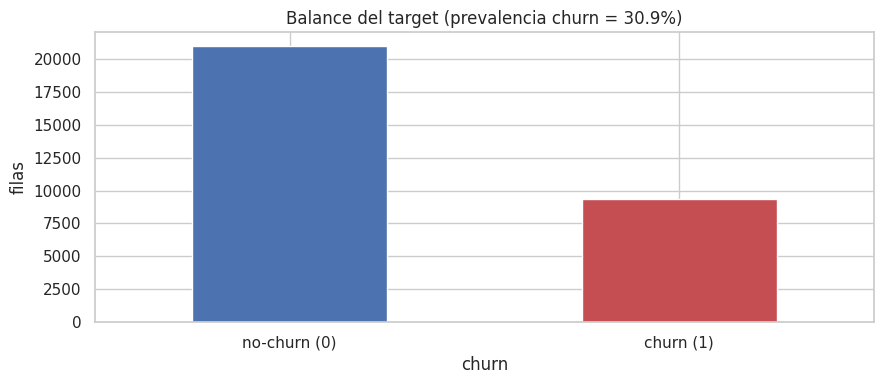

In [ ]:
vc = df[TARGET].value_counts().sort_index()
prev = df[TARGET].mean()
print(f"no-churn (0): {vc.get(0,0):,}\nchurn   (1): {vc.get(1,0):,}")
print(f"\nPREVALENCIA de churn: {prev:.4f}  ({prev*100:.1f}%)")
print(f"ratio no-churn:churn = {vc.get(0,0)/max(vc.get(1,1),1):.2f} : 1")

ax = vc.plot.bar(color=["#4c72b0", "#c44e52"])
ax.set_xticklabels(["no-churn (0)", "churn (1)"], rotation=0)
ax.set_title(f"Balance del target (prevalencia churn = {prev*100:.1f}%)")
ax.set_ylabel("filas")
plt.tight_layout(); plt.show()

## 2 · Estabilidad temporal del target

La validación de los papers es **out-of-period**: se entrena con el pasado y se
testea con meses futuros. Para que eso sea sensato, la prevalencia de churn no
debe pegar saltos bruscos entre periodos. Graficamos churn-rate por mes y el
volumen de observaciones (las ventanas de etiqueta requieren 6 meses de futuro,
por eso la serie corta antes del fin de los datos).


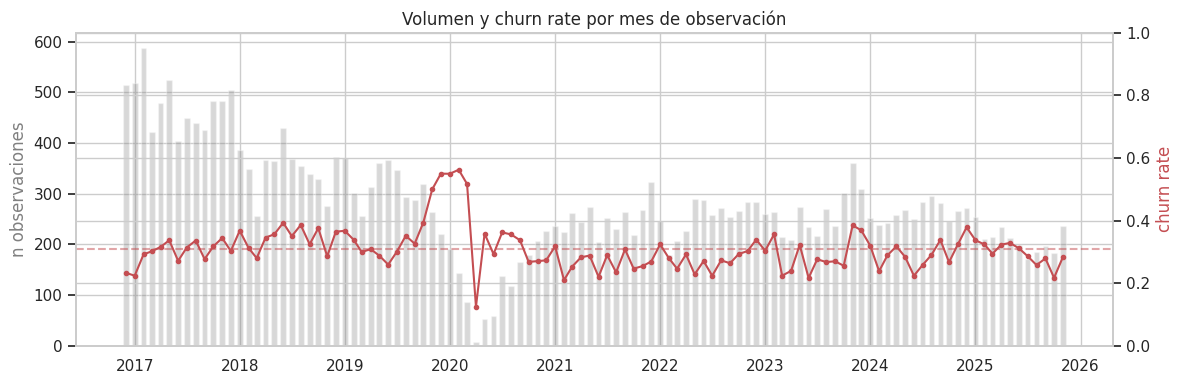

churn rate por año:
         size   mean
mes_obs             
2016      514  0.233
2017     5719  0.303
2018     4195  0.349
2019     3700  0.349
2020     1576  0.369
2021     2997  0.266
2022     3053  0.278
2023     3149  0.297
2024     3153  0.295
2025     2300  0.297


In [ ]:
serie = df.groupby(df["mes_obs"].dt.to_period("M").astype("datetime64[ns]")).agg(
    n=("churn", "size"), churn_rate=("churn", "mean"))

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(serie.index, serie["n"], width=20, alpha=0.3, color="gray", label="n obs")
ax1.set_ylabel("n observaciones", color="gray")
ax2 = ax1.twinx()
ax2.plot(serie.index, serie["churn_rate"], color="#c44e52", marker=".", label="churn rate")
ax2.axhline(df["churn"].mean(), ls="--", color="#c44e52", alpha=0.5)
ax2.set_ylabel("churn rate", color="#c44e52"); ax2.set_ylim(0, 1)
ax1.set_title("Volumen y churn rate por mes de observación")
plt.tight_layout(); plt.show()

print("churn rate por año:")
print(df.groupby(df["mes_obs"].dt.year)["churn"].agg(["size", "mean"]).round(3))

## 3 · Estructura del panel (multi-slicing)

Cada vendedora aparece en varios meses (slices). Cuántas filas tiene cada una
afecta a la validación: el split debe agrupar por vendedora para que la misma
no esté en train y test a la vez (lo que los papers llaman evitar el solape de
clientes entre folds).


vendedoras únicas: 6,323
filas por vendedora — describe:
count    6323.00
mean        4.80
std         6.96
min         1.00
25%         1.00
50%         2.00
75%         5.00
max        84.00
dtype: float64


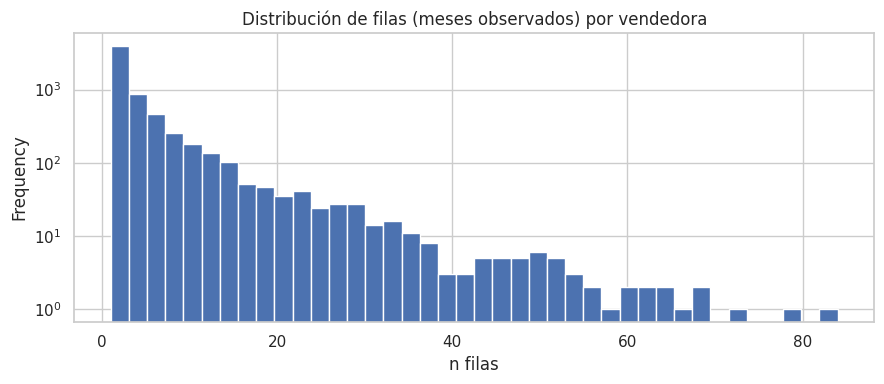

In [ ]:
filas_por_vend = df.groupby("id_vendedor").size()
print(f"vendedoras únicas: {df['id_vendedor'].nunique():,}")
print(f"filas por vendedora — describe:\n{filas_por_vend.describe().round(2)}")

ax = filas_por_vend.plot.hist(bins=40, color="#4c72b0")
ax.set_title("Distribución de filas (meses observados) por vendedora")
ax.set_xlabel("n filas"); ax.set_yscale("log")
plt.tight_layout(); plt.show()

## 4 · Completitud — nulos por columna

Las features RFM se construyen con sumas sobre ventanas, así que rara vez son
nulas. Los nulos esperables: `edad` (problema de `fecha_nacimiento`),
`monto_cv_u12` / tendencias (división cuando el denominador es 0) y geografía.


Columnas con nulos (%):
edad                      58.18
tend_monto_u3_vs_prev3    18.19
tend_nped_u3_vs_prev3     18.12
antiguedad_meses           0.32
monto_cv_u12               0.14
monto_ult_vs_media         0.14
tipo_vendedor              0.10
departamento               0.10
provincia                  0.10


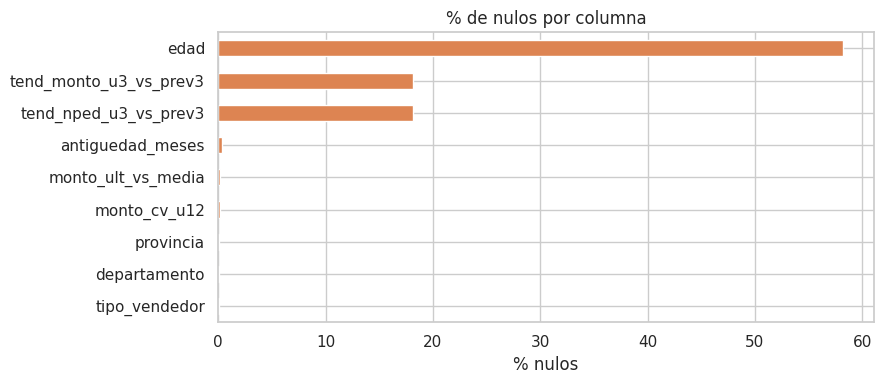

In [ ]:
nulos = (df.isna().mean() * 100).round(2)
nulos = nulos[nulos > 0].sort_values(ascending=False)
if len(nulos):
    print("Columnas con nulos (%):"); print(nulos.to_string())
    ax = nulos.sort_values().plot.barh(color="#dd8452")
    ax.set_title("% de nulos por columna"); ax.set_xlabel("% nulos")
    plt.tight_layout(); plt.show()
else:
    print("Sin nulos en ninguna columna.")

## 5 · Distribuciones de features numéricas

Estadísticos y forma de cada feature. Buscamos: colas largas (sesgo →
candidatas a transformación log), rangos, y valores centinela.


In [ ]:
df[NUM_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
meses_activos_u3,30356.0,1.91,0.76,1.00,1.00,2.00,2.00,3.00
meses_activos_u6,30356.0,2.89,1.46,1.00,2.00,3.00,4.00,6.00
meses_activos_u12,30356.0,4.28,2.72,1.00,2.00,3.00,6.00,12.00
n_ped_u3,30356.0,2.73,2.28,1.00,1.00,2.00,3.00,46.00
n_ped_u6,30356.0,4.25,3.94,1.00,2.00,3.00,5.00,82.00
n_ped_u12,30356.0,6.41,6.54,1.00,3.00,4.00,8.00,112.00
monto_u3,30356.0,1079.84,1388.34,0.00,395.95,731.84,1261.82,34534.09
monto_u6,30356.0,1721.53,2384.01,0.00,587.90,1083.75,1993.60,53527.24
monto_u12,30356.0,2664.89,4036.01,0.00,765.29,1487.77,3004.71,90545.57
monto_mean_u12,30356.0,340.88,445.67,0.00,109.23,232.76,412.92,8553.15


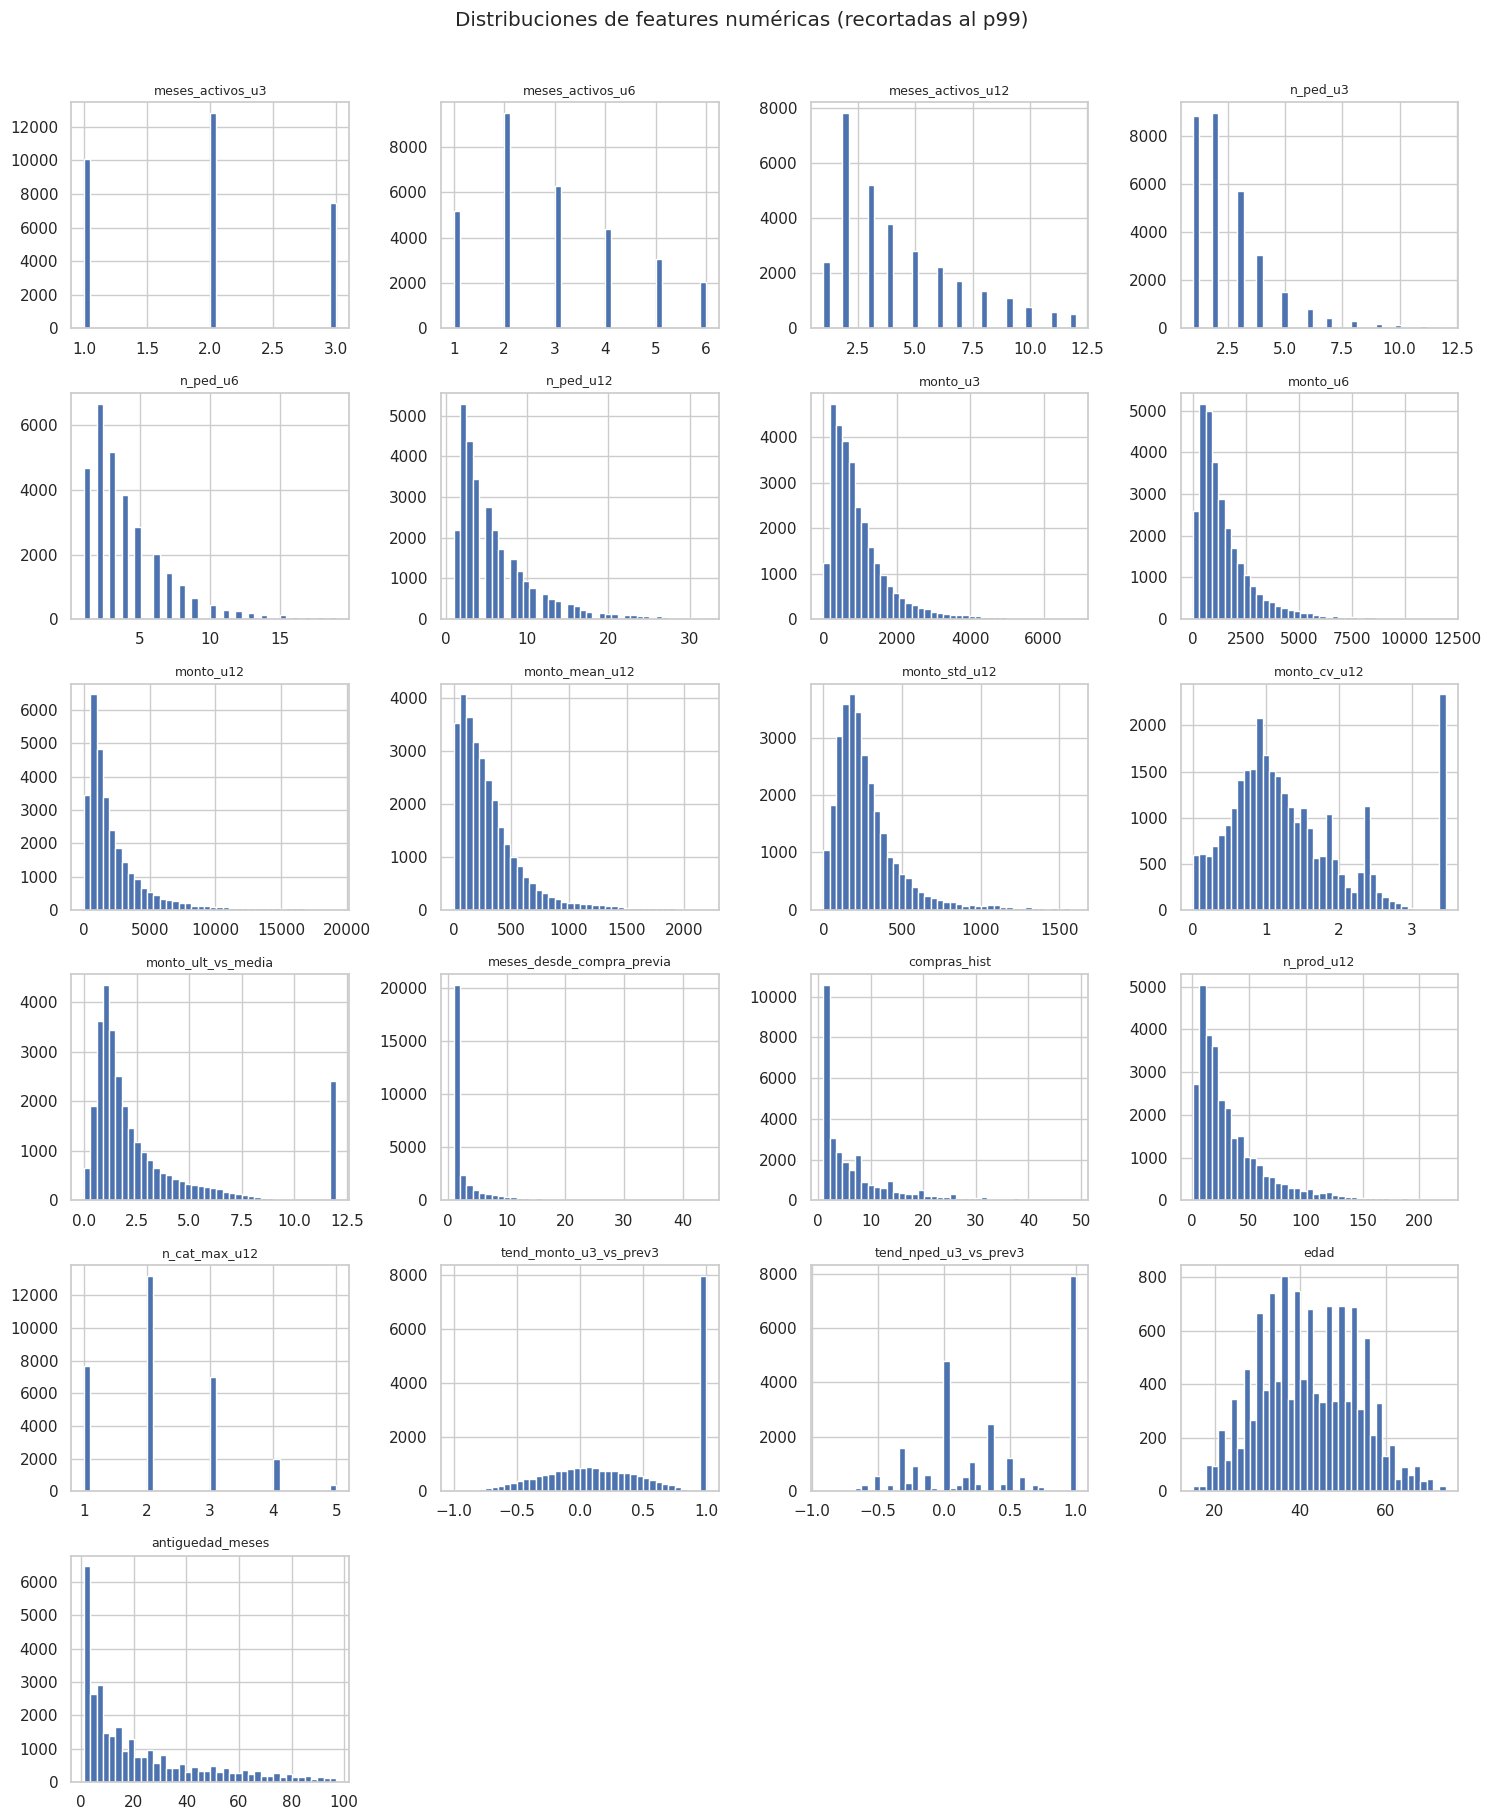

In [ ]:
n = len(NUM_COLS); ncol = 4; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 3 * nrow))
for ax, c in zip(axes.ravel(), NUM_COLS):
    s = df[c].dropna()
    # recortar al p99 para que la cola no aplaste el histograma
    hi = s.quantile(0.99)
    ax.hist(s[s <= hi], bins=40, color="#4c72b0")
    ax.set_title(c, fontsize=9)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("Distribuciones de features numéricas (recortadas al p99)", y=1.01)
plt.tight_layout(); plt.show()

## 6 · Features categóricas vs churn

Para cada categórica: cardinalidad, top valores y **churn-rate por categoría**
(con la prevalencia global como referencia). Una categoría cuyo churn-rate se
desvía mucho de la media aporta señal.


=== sexo === (3 valores únicos)
          n  churn_rate
sexo                   
OTRO    297       0.333
F     29327       0.311
M       732       0.228 

=== tipo_vendedor === (2 valores únicos)
                   n  churn_rate
tipo_vendedor                   
Asesora        27072        0.32
Líder           3254        0.22 

=== departamento === (34 valores únicos)
                 n  churn_rate
departamento                  
cajamarca     1609       0.351
la libertad   2221       0.343
piura         2471       0.327
junin         1959       0.323
lambayeque    1376       0.314
ancash        2165       0.279
Lima          1363       0.278
lima          4266       0.275 

=== provincia === (159 valores únicos)
              n  churn_rate
provincia                  
trujillo   1156       0.380
sullana     805       0.330
huamanga    821       0.326
satipo      935       0.324
chiclayo   1073       0.296
piura       973       0.294
lima       4165       0.276
huaraz     1028       0.195

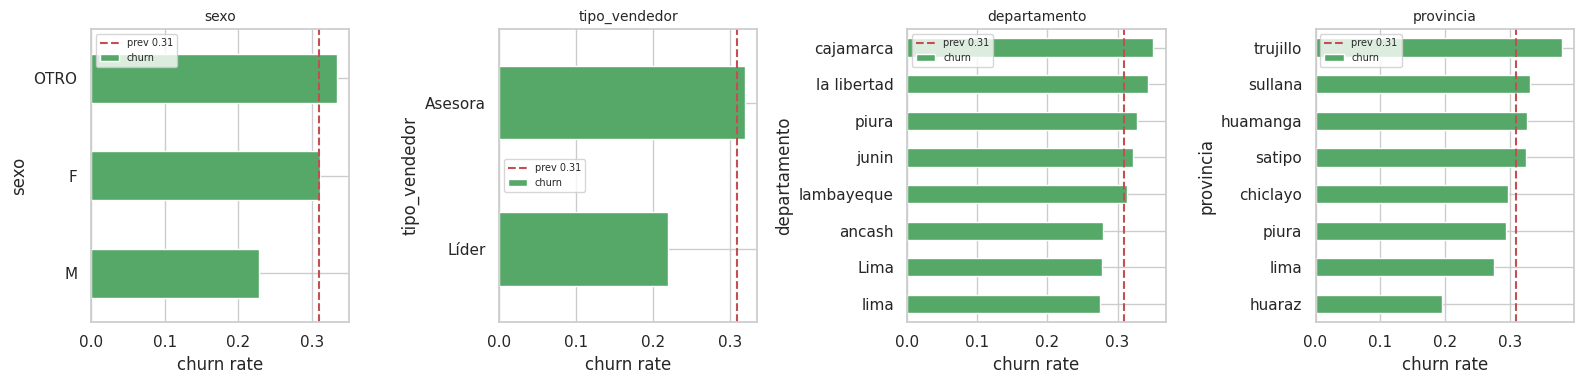

In [ ]:
prev = df["churn"].mean()
for c in CAT_COLS:
    print(f"=== {c} === ({df[c].nunique()} valores únicos)")
    top = df[c].value_counts(dropna=False).head(8).index
    tab = (df[df[c].isin(top)].groupby(c)["churn"]
           .agg(n="size", churn_rate="mean").sort_values("churn_rate", ascending=False))
    print(tab.round(3).to_string(), "\n")

fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(16, 4))
for ax, c in zip(axes, CAT_COLS):
    top = df[c].value_counts().head(8).index
    cr = df[df[c].isin(top)].groupby(c)["churn"].mean().sort_values()
    cr.plot.barh(ax=ax, color="#55a868")
    ax.axvline(prev, ls="--", color="#c44e52", label=f"prev {prev:.2f}")
    ax.set_title(c, fontsize=10); ax.set_xlabel("churn rate"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 7 · Poder predictivo univariado de las features numéricas

Para cada feature numérica calculamos el **AUC univariado**: qué tan bien, por
sí sola, ordena churners vs no-churners.

**Lectura del AUC orientado:** lo reportamos como `max(AUC, 1−AUC)`, de modo que
siempre queda **≥ 0.5** (0.5 = inútil, 1.0 = perfecto), igual que un AUC normal.
Un AUC crudo *por debajo de 0.5* solo indica que la feature es **inversa** al
churn (a mayor valor, menos churn) — discrimina igual de bien, en sentido
contrario. Por eso guardamos la **dirección** en una columna aparte:

- **`−`** (azul): a mayor valor de la feature, **menos** churn (ej. más facturación, más pedidos).
- **`+`** (rojo): a mayor valor, **más** churn (ej. más meses desde la compra previa).

Confirmamos si, como dicen los papers, el **CV de facturación** y el
**desarrollo reciente** están entre las más fuertes.

Ranking de poder predictivo univariado (AUC orientado, 0.5 = sin señal):
  direccion  +: a mayor valor de la feature, mas churn  |  -: a mayor valor, menos churn

                  feature   auc direccion  media_churn  media_no_churn
                monto_u12 0.720         -     1341.920        3257.228
               n_prod_u12 0.720         -       20.412          45.409
                n_ped_u12 0.716         -        3.855           7.555
                 monto_u6 0.715         -      938.915        2071.925
                 n_ped_u6 0.706         -        2.761           4.918
        meses_activos_u12 0.695         -        3.033           4.835
                 monto_u3 0.693         -      651.849        1271.461
         meses_activos_u6 0.688         -        2.226           3.190
           monto_mean_u12 0.687         -      204.006         402.160
                 n_ped_u3 0.676         -        1.950           3.083
            monto_std_u12 0.668         -      209.733  

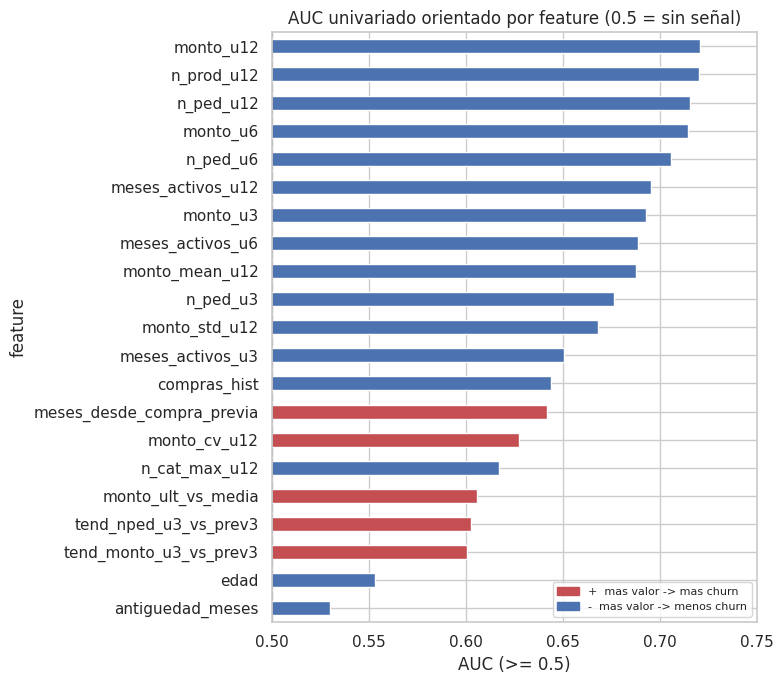

In [ ]:
rows = []
y = df["churn"].values
for c in NUM_COLS:
    s = df[c]
    mask = s.notna().values
    if mask.sum() < 100 or s[mask].nunique() < 2:
        continue
    raw = roc_auc_score(y[mask], s[mask].values)
    # AUC ORIENTADO: siempre >= 0.5 (convención estándar). Un AUC crudo < 0.5
    # NO significa que la feature sea mala, sino que es INVERSA al churn.
    # max(raw, 1-raw) reporta la capacidad discriminativa real; la dirección
    # se guarda aparte.
    auc = max(raw, 1 - raw)
    rows.append({"feature": c,
                 "auc": auc,                                  # AUC normal (>= 0.5)
                 "direccion": "+" if raw >= 0.5 else "-",     # +: a mayor valor, mas churn
                 "media_churn": df.loc[df.churn == 1, c].mean(),
                 "media_no_churn": df.loc[df.churn == 0, c].mean()})
rank = pd.DataFrame(rows).sort_values("auc", ascending=False).reset_index(drop=True)
print("Ranking de poder predictivo univariado (AUC orientado, 0.5 = sin señal):")
print("  direccion  +: a mayor valor de la feature, mas churn  |  -: a mayor valor, menos churn\n")
print(rank[["feature", "auc", "direccion", "media_churn", "media_no_churn"]].round(3).to_string(index=False))

# barras: color por direccion, eje desde 0.5
colores = rank["direccion"].map({"+": "#c44e52", "-": "#4c72b0"})
ax = rank.set_index("feature")["auc"].iloc[::-1].plot.barh(
    figsize=(8, 7), color=colores.iloc[::-1])
ax.axvline(0.5, ls="--", color="gray")
ax.set_xlim(0.5, max(0.75, rank["auc"].max() + 0.02))
ax.set_title("AUC univariado orientado por feature (0.5 = sin señal)")
ax.set_xlabel("AUC (>= 0.5)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#c44e52", label="+  mas valor -> mas churn"),
                   Patch(color="#4c72b0", label="-  mas valor -> menos churn")], fontsize=8)
plt.tight_layout(); plt.show()

## 8 · Redundancia — correlación entre features numéricas

Las ventanas u3/u6/u12 de la misma magnitud están correlacionadas por
construcción (u3 ⊂ u6 ⊂ u12). Alta correlación no rompe a un random forest, pero
conviene conocerla para interpretar importancias y para modelos lineales.


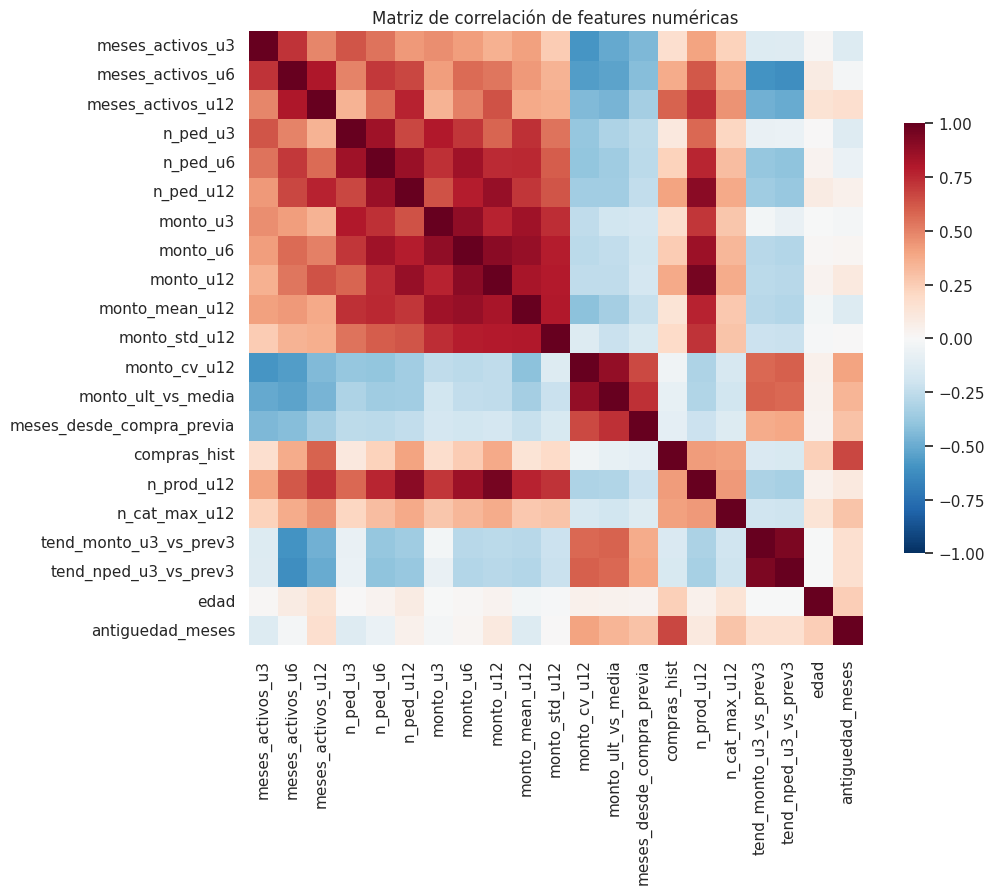

Pares con |correlación| > 0.85 (12):
                    f1                    f2     r
             monto_u12            n_prod_u12 0.961
tend_monto_u3_vs_prev3 tend_nped_u3_vs_prev3 0.941
              monto_u6             monto_u12 0.904
             n_ped_u12            n_prod_u12 0.904
              monto_u3              monto_u6 0.890
          monto_cv_u12    monto_ult_vs_media 0.882
             n_ped_u12             monto_u12 0.873
              monto_u6        monto_mean_u12 0.869
              n_ped_u6             n_ped_u12 0.864
              monto_u6            n_prod_u12 0.858
              n_ped_u3              n_ped_u6 0.851
              monto_u3        monto_mean_u12 0.850


In [ ]:
corr = df[NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Matriz de correlación de features numéricas")
plt.tight_layout(); plt.show()

# pares más correlacionados (|r| > 0.85)
pares = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack().reset_index())
pares.columns = ["f1", "f2", "r"]
altos = pares[pares["r"].abs() > 0.85].sort_values("r", key=abs, ascending=False)
print(f"Pares con |correlación| > 0.85 ({len(altos)}):")
print(altos.round(3).to_string(index=False))

## 9 · Síntesis — hallazgos del EDA del dataset

> **Completar tras correr el notebook.** Plantilla para volcar los números reales:

**Target**
- Prevalencia de churn: __% — desbalance moderado → `class_weight='balanced'` (no resampling).
- Estabilidad temporal: ¿la churn-rate por mes se mantiene cerca de la media o hay drift?

**Estructura**
- Vendedoras: … | filas/vendedora: mediana … → el split debe agrupar por vendedora.

**Completitud**
- Nulos relevantes: `edad` (~__%), … → estrategia de imputación en preprocessing.

**Señal (AUC univariado)**
- Top features: … ¿Aparecen `monto_cv_u12` y `monto_ult_vs_media` arriba, como en los papers?
- Features sin señal (AUC ≈ 0.5): … → candidatas a descartar.

**Redundancia**
- Pares muy correlacionados: … (ventanas RFM solapadas).

**Próximo paso (CRISP-DM):** *Data Preparation* — encoding de categóricas,
imputación de `edad`, y definir el split out-of-period + CV por vendedora.
